In [56]:
from luxai_s3.wrappers import LuxAIS3GymEnv 
import numpy as np
from base import BaseAgent, direction_to

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tensorflow as tf
from pathlib import Path

In [2]:
from matplotlib.colors import ListedColormap
    
OUT_VISION = "#27213C"
EMPTY_C = "#F1E0C5"
NEBULA_C = "#477998"
ASTEROID_C = "#5B3000"

CMAP_TILES = ListedColormap([OUT_VISION, EMPTY_C, NEBULA_C, ASTEROID_C])  

RED = '#4CAF50'
GREEN = '#F44336'

def show_grid(grid):
    plt.figure(figsize=(7, 6))
    sns.heatmap(grid, cbar=True, linewidths=0.5, linecolor='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title("Grid")
    plt.show()

def show_tiles(tiles):
    plt.figure(figsize=(7, 6))
    sns.heatmap(tiles, cmap=CMAP_TILES, cbar=True, linewidths=0.5, linecolor='gray', vmin=-1, vmax=2)
    plt.xticks([])
    plt.yticks([])
    plt.title("Tiles", fontsize=14)
    plt.show()

In [3]:
class Agent():
    def __init__(self, player: str, env_cfg) -> None:
        self.player = player
        self.opp_player = "player_1" if self.player == "player_0" else "player_0"
        self.team_id = 0 if self.player == "player_0" else 1
        self.opp_team_id = 1 if self.team_id == 0 else 0
        np.random.seed(0)
        self.env_cfg = env_cfg
        
        self.relic_node_positions = []
        self.discovered_relic_nodes_ids = set()
        self.unit_explore_locations = dict()

        self.map_tiles = None

    def act(self, step: int, obs, remainingOverageTime: int = 60):
        """implement this function to decide what actions to send to each available unit. 
        
        step is the current timestep number of the game starting from 0 going up to max_steps_in_match * match_count_per_episode - 1.
        """
        unit_mask = np.array(obs["units_mask"][self.team_id]) # shape (max_units, )
        unit_positions = np.array(obs["units"]["position"][self.team_id]) # shape (max_units, 2)
        unit_energys = np.array(obs["units"]["energy"][self.team_id]) # shape (max_units, 1)
        self.map_tiles = np.array(obs["map_features"]["tile_type"])
        observed_relic_node_positions = np.array(obs["relic_nodes"]) # shape (max_relic_nodes, 2)
        observed_relic_nodes_mask = np.array(obs["relic_nodes_mask"]) # shape (max_relic_nodes, )
        team_points = np.array(obs["team_points"]) # points of each team, team_points[self.team_id] is the points of the your team
        
        # ids of units you can control at this timestep
        available_unit_ids = np.where(unit_mask)[0]
        # visible relic nodes
        visible_relic_node_ids = set(np.where(observed_relic_nodes_mask)[0])
        
        actions = np.zeros((self.env_cfg["max_units"], 3), dtype=int)


        # basic strategy here is simply to have some units randomly explore and some units collecting as much energy as possible
        # and once a relic node is found, we send all units to move randomly around the first relic node to gain points
        # and information about where relic nodes are found are saved for the next match
        
        # save any new relic nodes that we discover for the rest of the game.
        for id in visible_relic_node_ids:
            if id not in self.discovered_relic_nodes_ids:
                self.discovered_relic_nodes_ids.add(id)
                self.relic_node_positions.append(observed_relic_node_positions[id])
            

        # unit ids range from 0 to max_units - 1
        for unit_id in available_unit_ids:
            unit_pos = unit_positions[unit_id]
            unit_energy = unit_energys[unit_id]
            if len(self.relic_node_positions) > 0:
                nearest_relic_node_position = self.relic_node_positions[0]
                manhattan_distance = abs(unit_pos[0] - nearest_relic_node_position[0]) + abs(unit_pos[1] - nearest_relic_node_position[1])
                
                # if close to the relic node we want to hover around it and hope to gain points
                if manhattan_distance <= 4:
                    random_direction = np.random.randint(0, 5)
                    actions[unit_id] = [random_direction, 0, 0]
                else:
                    # otherwise we want to move towards the relic node
                    actions[unit_id] = [direction_to(unit_pos, nearest_relic_node_position), 0, 0]
            else:
                # randomly explore by picking a random location on the map and moving there for about 20 steps
                if step % 20 == 0 or unit_id not in self.unit_explore_locations:
                    rand_loc = (np.random.randint(0, self.env_cfg["map_width"]), np.random.randint(0, self.env_cfg["map_height"]))
                    self.unit_explore_locations[unit_id] = rand_loc
                actions[unit_id] = [direction_to(unit_pos, self.unit_explore_locations[unit_id]), 0, 0]
        return actions

    def get_map_tiles(self):
        return self.map_tiles

In [57]:
from enum import Enum

class AgentError(Exception):
    pass

class Move(Enum):
    CENTER = (0, [0, 0])
    UP = (1, [-1, 0])
    RIGHT = (2, [0, 1])
    DOWN = (3, [1, 0])
    LEFT = (4, [0, -1])


class MyAgent():
    def __init__(self, player: str, env_cfg, save_dir) -> None:
        self.save_dir = save_dir
        Path(save_dir).mkdir(parents=True, exist_ok=True)

        self.player = player
        self.opp_player = "player_1" if self.player == "player_0" else "player_0"
        self.team_id = 0 if self.player == "player_0" else 1
        self.opp_team_id = 1 if self.team_id == 0 else 0
        self.env_cfg = env_cfg

        self.tiles_covered = False
        self.known_tiles = {}
        self.tiles_movements = []
        self.actual_tiles = self.make_actual_tiles(0)

        self.known_energies = np.full((24,24), -1)
        self.energies_movements = []

    def act(self, step: int, obs):
        unit_mask = np.array(obs["units_mask"][self.team_id]) 
        unit_pos = obs["units"]["position"][self.team_id]
        unit_ene = obs["units"]["energy"][self.team_id]
        vision = obs["sensor_mask"]
        energies = obs["map_features"]["energy"]
        tiles = obs["map_features"]["tile_type"]

        # ids of units you can control at this timestep
        available_unit_ids = np.where(unit_mask)[0]

        actions = np.zeros((16, 3), dtype=int)

        # save 0 (obserations)
        self.save_tiles(step, tiles)

        # update map
        self.detect_tiles_movement(tiles, step)
        self.update_tiles(tiles, step)
        self.update_energies(energies)
        
        # explore map
        if not self.tiles_covered:
            actions = self.explore_tiles(available_unit_ids, unit_pos, step)

        # save 1 (computed)
        self.save_actual_tiles(step)
        
        return actions
    
    # ----------------------- Save -------------------
    
    def save_actual_tiles(self, step):
        if self.player == "player_0":
            file_path = self.save_dir + f"/actual_tiles_{step}.csv"
            csv_tiles = pd.DataFrame(self.actual_tiles)
            csv_tiles.to_csv(file_path, index=False)

    def save_tiles(self, step, tiles):
        if self.player == "player_0":
            file_path = self.save_dir + f"/tiles_{step}.csv"
            csv_tiles = pd.DataFrame(tiles)
            csv_tiles.to_csv(file_path, index=False)


    # --------------------------- Detect Tile Movement ------------------
    
    def detect_tiles_movement(self, tiles, step):
        pass

    # ------------------- Update tile -------------------------

    def update_tiles(self, tiles, step):
        for x, line in enumerate(tiles):
            for y, tile in enumerate(line):
                if tile != -1:
                    self.set_tile(step, x, y, tile)

        self.actual_tiles = self.make_actual_tiles(step)

    def set_tile(self, step, x, y, tile):
        x_ref = x
        y_ref = y

        # Determine x and y in reference space
        for movement in self.tiles_movements:
            if step >= movement["step"]:
                x_ref -= movement["movement"][0]
                y_ref -= movement["movement"][1]

        # If row has already been initialized
        if x_ref in self.known_tiles.keys():
            # If line exists
            if y_ref in self.known_tiles[x_ref].keys():
                # Check if tile match the first one
                if self.known_tiles[x_ref][y_ref] != tile:
                    raise AgentError(
                        f"Inconsistence when assigning tiles. Recieved [{step=} {x=}, {y=}, {tile=}],"
                        f" but the value is already set to : [{step=}, {x_ref=}, {y_ref=}, tile={self.known_tiles[x_ref][y_ref]}]"
                    )
            # Create the line
            else : 
                self.known_tiles[x_ref][y_ref] = tile
        # Create the row
        else:
            self.known_tiles[x_ref] = {y_ref: tile}

    # ---------------------------------- Access Tiles ----------------------------

    def make_actual_tiles(self, step):
        x_min = 0
        x_max = self.env_cfg["map_height"]
        y_min = 0
        y_max = self.env_cfg["map_width"]

        # Determine step maxi and mini
        for movement in self.tiles_movements:
            if step >= movement["step"]:
                x_min -= movement["movement"][0]
                x_max -= movement["movement"][0]
                y_min -= movement["movement"][1]
                y_max -= movement["movement"][1]

        # Make tiles map
        map_tiles = []
        for x_ref in range(x_min, x_max):
            line = []
            for y_ref in range(y_min, y_max):
                tile = -1
                if (x_ref in self.known_tiles.keys()) and (y_ref in self.known_tiles[x_ref].keys()):
                    tile = self.known_tiles[x_ref][y_ref]
                line.append(tile)
            map_tiles.append(line)

        return map_tiles
    
    
    # ------------------------- Explore tiles -------------------------

    def explore_tiles(self, available_unit_ids, unit_pos, step):
        # useful: actual_tiles, known_energies, unit_pos
        return self.random_exploration(available_unit_ids, unit_pos, step)
        
    
    def random_exploration(self, available_unit_ids, unit_pos, step):
        actions = np.zeros((16, 3), dtype=int)

        for unit_id in available_unit_ids:
            pos = unit_pos[unit_id]
            move = self.random_move(pos, step)

            actions[unit_id] = [move, 0, 0]
        return actions

    def random_move(self, pos, step) -> int:
        moves = list(Move)
        np.random.shuffle(moves)

        for m in moves:
            new_pos = self.move_unit(pos, m)
            if self.valid_pos(new_pos, step):
                return m.value[0]
        raise Exception(f"No possible moves for this unit: {pos=}")
    
    def move_unit(self, pos, m):
        return [pos[i] + m.value[1][i] for i in range(2)] 

    def valid_pos(self, pos, step) -> bool:
        # If out of bounds
        if (pos[0] < 0) or (pos[0] >= 24):
            return False
        if (pos[1] < 0) or (pos[1] >= 24):
            return False

        # If on asteroid
        if self.actual_tiles[pos[0]][pos[1]] == 2:
            return False
        
        return True

    # ------------------------------- Update Energies -------------------

    def update_energies(self, energies):
        pass

In [5]:
# Set environment
env = LuxAIS3GymEnv(numpy_output=True)
obs, info = env.reset()
env_cfg = info["params"]

# Initialise agents
player_0 = MyAgent("player_0", env_cfg)
player_1 = MyAgent("player_1", env_cfg)

In [6]:
env_cfg

{'max_units': 16,
 'match_count_per_episode': 5,
 'max_steps_in_match': 100,
 'map_height': 24,
 'map_width': 24,
 'num_teams': 2,
 'unit_move_cost': 4,
 'unit_sap_cost': 45,
 'unit_sap_range': 3,
 'unit_sensor_range': 2}

In [7]:
env_cfg

{'max_units': 16,
 'match_count_per_episode': 5,
 'max_steps_in_match': 100,
 'map_height': 24,
 'map_width': 24,
 'num_teams': 2,
 'unit_move_cost': 4,
 'unit_sap_cost': 45,
 'unit_sap_range': 3,
 'unit_sensor_range': 2}

In [8]:
# Initialise match
obs, info = env.reset()
env_cfg = info["params"]
observations = []

# Store all observations of a match
for i in range(env_cfg["max_steps_in_match"]):
        # Take action 
    actions = {}
    for agent in [player_0, player_1]:
        actions[agent.player] = agent.act(step=i, obs=obs[agent.player])

    obs, rewards ,terminated, truncated, info = env.step(actions)
    observations.append(obs)

len(observations)

Exception: Inconsistence when assigning tiles. Recieved [step=21 x=0, y=1, tile=np.int32(1)], but the value is already set to : [step=21, x_ref=0, y_ref=1, tile=0]

{}

## Detect shift

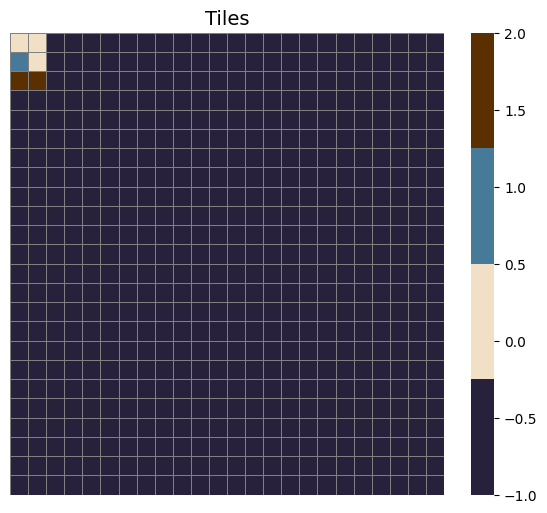

In [9]:
actual = pd.read_csv("../references/tiles/actual_tiles_20.csv")
show_tiles(actual.to_numpy())

In [15]:
actual_tiles = actual.to_numpy().tolist()
actual_tiles

[[0,
  0,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1],
 [1,
  0,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1],
 [2,
  2,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1],
 [-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1

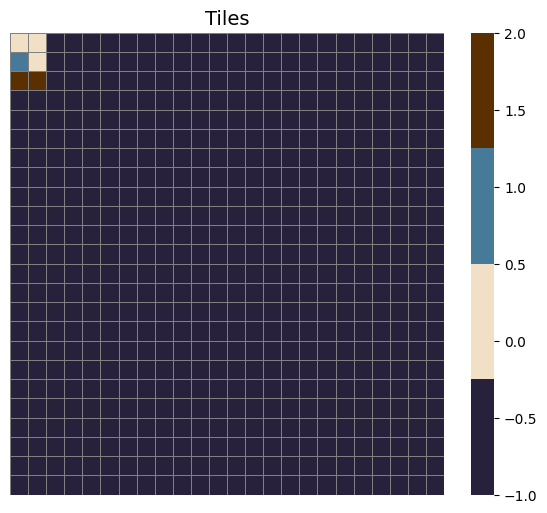

In [18]:
tiles = pd.read_csv("../references/tiles/tiles_20.csv")
show_tiles(tiles.to_numpy())

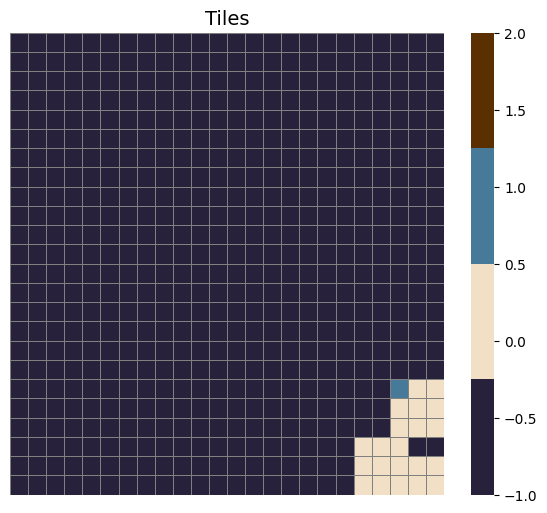

In [ ]:
tiles = pd.read_csv("../references/tiles/tiles_15.csv")
show_tiles(tiles.to_numpy())

In [58]:
import json
from IPython.display import display, Javascript
from luxai_s3.wrappers import LuxAIS3GymEnv, RecordEpisode

def render_episode(episode: RecordEpisode) -> None:
    data = json.dumps(episode.serialize_episode_data(), separators=(",", ":"))
    display(Javascript(f"""
var iframe = document.createElement('iframe');
iframe.src = 'https://s3vis.lux-ai.org/#/kaggle';
iframe.width = '100%';
iframe.scrolling = 'no';

iframe.addEventListener('load', event => {{
    event.target.contentWindow.postMessage({data}, 'https://s3vis.lux-ai.org');
}});

new ResizeObserver(entries => {{
    for (const entry of entries) {{
        entry.target.height = `${{Math.round(320 + 0.3 * entry.contentRect.width)}}px`;
    }}
}}).observe(iframe);

element.append(iframe);
    """))

def play_games(agent_1_cls, agent_2_cls, nb_games=1, seed=None, games_to_play=3, replay_save_dir="replays", render=False):
    for game in range(nb_games):
        play_game(agent_1_cls, agent_2_cls, seed=seed, games_to_play=games_to_play, 
                   replay_save_dir=replay_save_dir + f"/game_{game}", render=render)
    

def play_game(agent_1_cls, agent_2_cls, seed=None, games_to_play=3, replay_save_dir="replays", render=False):
    env = RecordEpisode(
        LuxAIS3GymEnv(numpy_output=True), save_on_close=True, save_on_reset=True, save_dir=replay_save_dir
    )

    obs, info = env.reset(seed=seed)
    for i in range(games_to_play):
        obs, info = env.reset()
        env_cfg = info["params"] # only contains observable game parameters
        player_0 = agent_1_cls("player_0", env_cfg, replay_save_dir)
        player_1 = agent_2_cls("player_1", env_cfg, replay_save_dir)
    
        # main game loop
        game_done = False
        step = 0
        print(f"Running game {i}")

        while not game_done:
            actions = dict()

            try:
                for agent in [player_0, player_1]:
                    actions[agent.player] = agent.act(step=step, obs=obs[agent.player])
                    
                obs, reward, terminated, truncated, info = env.step(actions)
                # info["state"] is the environment state object, you can inspect/play around with it to e.g. print
                # unobservable game data that agents can't see
                dones = {k: terminated[k] | truncated[k] for k in terminated}

                if dones["player_0"] or dones["player_1"]:
                    game_done = True

                step += 1

            except AgentError:
                print(f"game={replay_save_dir[-1]}, {step=}")
                game_done = True
                step += 1
            
        if render:
            render_episode(env)
        
    env.close() # free up resources and save final replay

In [60]:
play_games(
    MyAgent, MyAgent,
    seed=None,
    nb_games=100, games_to_play=1,
    replay_save_dir="replays", 
    render=False
)

Running game 0
game=0, step=21
Running game 0
game=1, step=21
Running game 0
game=2, step=21
Running game 0
game=3, step=21
Running game 0
game=4, step=21
Running game 0
game=5, step=21
Running game 0
game=6, step=21
Running game 0
game=7, step=21
Running game 0
game=8, step=21
Running game 0
game=9, step=21
Running game 0
game=0, step=21
Running game 0
game=1, step=21
Running game 0
game=2, step=21
Running game 0
game=3, step=21
Running game 0
game=4, step=21
Running game 0
game=5, step=21
Running game 0
game=6, step=21
Running game 0
game=7, step=21
Running game 0
game=8, step=21
Running game 0
game=9, step=21
Running game 0
game=0, step=21
Running game 0
game=1, step=21
Running game 0
game=2, step=21
Running game 0
game=3, step=21
Running game 0
game=4, step=21
Running game 0
game=5, step=21
Running game 0
game=6, step=21
Running game 0
game=7, step=21
Running game 0
game=8, step=21
Running game 0
game=9, step=21
Running game 0
game=0, step=21
Running game 0
game=1, step=21
Running 

: 

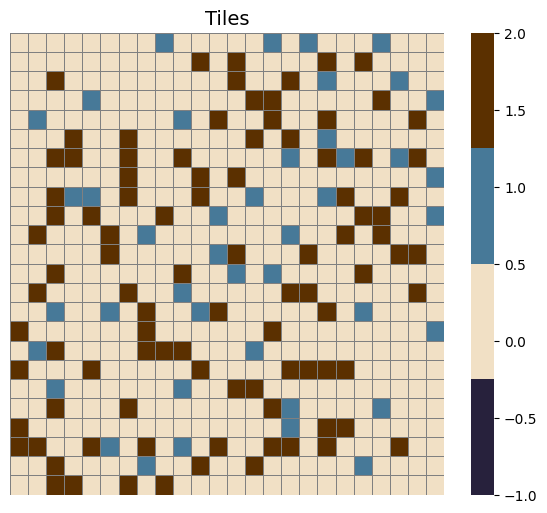

In [38]:
def set_tile(proba):
    if proba < 0.8:
        return 0
    if proba < 0.93:
        return 2
    return 1

def generate_random_tiles(seed=None):
    np.random.seed(seed)
    map_tiles = [
        [set_tile(proba) for proba in np.random.uniform(size=24)]
        for _ in range(24)
    ]

    # Copy upper triangle
    for i in range(len(map_tiles)):
        for j in range(24 - i):
            x = 23 - j
            y = 23 - i
            map_tiles[x][y] = map_tiles[i][j]
    return map_tiles

map_tiles = generate_random_tiles()
show_tiles(map_tiles)

In [20]:
np.random.uniform(size=100)

array([0.94994396, 0.81444208, 0.384785  , 0.18263709, 0.76002362,
       0.71883377, 0.50339566, 0.27313251, 0.11171802, 0.86499188,
       0.70776803, 0.1783043 , 0.72253194, 0.77341147, 0.26002779,
       0.87885406, 0.95862544, 0.21959088, 0.57934654, 0.30199449,
       0.78668044, 0.40277514, 0.77132011, 0.37455897, 0.99163589,
       0.63502116, 0.48011066, 0.33329657, 0.87086446, 0.4026677 ,
       0.3701877 , 0.23534308, 0.39737076, 0.1759204 , 0.75638555,
       0.72664473, 0.07566541, 0.25978929, 0.22955806, 0.77884308,
       0.0364514 , 0.11099509, 0.90077912, 0.01888022, 0.28062995,
       0.2245711 , 0.02091219, 0.49221688, 0.23647623, 0.1288132 ,
       0.80679782, 0.14822292, 0.89539878, 0.85961841, 0.81222878,
       0.45156559, 0.0576248 , 0.5399536 , 0.2195118 , 0.28940582,
       0.44432986, 0.70979244, 0.69448933, 0.06458236, 0.5222735 ,
       0.15599129, 0.17306226, 0.39960646, 0.70405849, 0.92931728,
       0.7951084 , 0.89019117, 0.20489337, 0.48407947, 0.14739